<a href="https://colab.research.google.com/github/heetaamin/ml-assignment2/blob/main/Assignment%203/Dermatology/baseline_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

data_dir = '/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 3/Dermatology/'

# fixed seed while the code is built and tested - the actual sweep
# will loop over multiple seeds per architecture
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(torch.__version__)

Mounted at /content/drive
2.11.0+cpu


# Loading the split data and scaling and encoding

In [ ]:
# load the split we froze in modelling_prep - never regenerate it
train_df = pd.read_csv(data_dir + "split_train.csv")
val_df = pd.read_csv(data_dir + "split_val.csv")
test_df = pd.read_csv(data_dir + "split_test.csv")

feature_cols = [c for c in train_df.columns if c != "class"]

X_train, y_train = train_df[feature_cols], train_df["class"]
X_val, y_val = val_df[feature_cols], val_df["class"]
X_test, y_test = test_df[feature_cols], test_df["class"]

# scale - fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# encode labels by minority -> majority rank, fixed across the whole project
minority_to_majority_order = [6, 4, 5, 2, 3, 1]  # pityriasis_rubra_pilaris, pityriasis_rosea, chronic_dermatitis, seboreic_dermatitis, lichen_planus, psoriasis
CLASS_NAMES = {1: "psoriasis", 2: "seboreic_dermatitis", 3: "lichen_planus",
               4: "pityriasis_rosea", 5: "chronic_dermatitis", 6: "pityriasis_rubra_pilaris"}
label_to_index = {label: i for i, label in enumerate(minority_to_majority_order)}
index_to_label = {i: label for label, i in label_to_index.items()}

y_train_idx = y_train.map(label_to_index).values
y_val_idx = y_val.map(label_to_index).values
y_test_idx = y_test.map(label_to_index).values

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
print(label_to_index)

Train: 233  Val: 59  Test: 74
{6: 0, 4: 1, 5: 2, 2: 3, 3: 4, 1: 5}


# Convert to tensors

In [ ]:
# torch wants float32 for inputs and long (int64) for class indices
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_t = torch.tensor(y_train_idx, dtype=torch.long)
y_val_t = torch.tensor(y_val_idx, dtype=torch.long)
y_test_t = torch.tensor(y_test_idx, dtype=torch.long)

print(X_train_t.shape, y_train_t.shape)

torch.Size([233, 34]) torch.Size([233])


# Defining a growable network

In [ ]:
class GrowableNet(nn.Module):
    """
    A single-hidden-layer network that can grow one hidden neuron or
    one output class at a time, keeping all previously learned weights.

    With hidden_dim = 0, there's no hidden layer at all - inputs map
    straight to outputs (this is what "start with the simplest
    architecture" means for stage 1).
    """
    def __init__(self, input_dim, output_dim, hidden_dim=0):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        if hidden_dim == 0:
            self.fc_hidden = None
            self.fc_out = nn.Linear(input_dim, output_dim)
        else:
            self.fc_hidden = nn.Linear(input_dim, hidden_dim)
            self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        if self.hidden_dim == 0:
            return self.fc_out(x)
        h = torch.tanh(self.fc_hidden(x))
        return self.fc_out(h)

    def add_hidden_neuron(self):
        """Grow the hidden layer by one neuron. Existing weights are copied
        across untouched, only the new neuron's weights are freshly
        initialised. Going from 0 to 1 hidden neuron is the one exception -
        there's no existing hidden layer to preserve, so this is a genuine
        architecture change, not a weight-preserving expansion."""
        if self.hidden_dim == 0:
            self.fc_hidden = nn.Linear(self.input_dim, 1)
            self.fc_out = nn.Linear(1, self.output_dim)
            self.hidden_dim = 1
            return

        old_dim = self.hidden_dim
        new_dim = old_dim + 1

        new_fc_hidden = nn.Linear(self.input_dim, new_dim)
        with torch.no_grad():
            new_fc_hidden.weight[:old_dim] = self.fc_hidden.weight
            new_fc_hidden.bias[:old_dim] = self.fc_hidden.bias
        self.fc_hidden = new_fc_hidden

        new_fc_out = nn.Linear(new_dim, self.output_dim)
        with torch.no_grad():
            new_fc_out.weight[:, :old_dim] = self.fc_out.weight
            new_fc_out.bias[:] = self.fc_out.bias
        self.fc_out = new_fc_out

        self.hidden_dim = new_dim

    def add_output_class(self):
        """Grow the output layer by one class. All existing output
        neurons keep their learned weights - only the new class's
        output neuron is freshly initialised."""
        old_dim = self.output_dim
        new_dim = old_dim + 1
        in_features = self.hidden_dim if self.hidden_dim > 0 else self.input_dim

        new_fc_out = nn.Linear(in_features, new_dim)
        with torch.no_grad():
            new_fc_out.weight[:old_dim] = self.fc_out.weight
            new_fc_out.bias[:old_dim] = self.fc_out.bias
        self.fc_out = new_fc_out

        self.output_dim = new_dim


# quick sanity check - build a tiny net and grow it, just to see it doesn't error out
test_net = GrowableNet(input_dim=34, output_dim=2, hidden_dim=0)
print(test_net)
test_net.add_hidden_neuron()
print(test_net)
test_net.add_output_class()
print(test_net)

GrowableNet(
  (fc_out): Linear(in_features=34, out_features=2, bias=True)
)
GrowableNet(
  (fc_out): Linear(in_features=1, out_features=2, bias=True)
  (fc_hidden): Linear(in_features=34, out_features=1, bias=True)
)
GrowableNet(
  (fc_out): Linear(in_features=1, out_features=3, bias=True)
  (fc_hidden): Linear(in_features=34, out_features=1, bias=True)
)


# No skill baseline - reference point for a still high loss

In [ ]:
def no_skill_loss(y_indices, num_classes):
    """Cross-entropy loss of a classifier that just predicts each class's
    prior frequency - our reference point for what 'no better than
    guessing' looks like, given whichever classes are active right now."""
    counts = np.bincount(y_indices, minlength=num_classes)
    p = counts / counts.sum()
    p = p[p > 0]  # a class with 0 instances contributes nothing
    return -np.sum(p * np.log(p))

# Selecting which classes are active at a given stage

In [ ]:
def select_active(X_t, y_t, num_active_classes):
    """Our label encoding is ordered minority -> majority, so the
    'active classes' at any stage are always indices 0..num_active-1.
    This slices train/val/test down to just those classes."""
    mask = y_t < num_active_classes
    return X_t[mask], y_t[mask]

# The training loop: mini-batches, patience, restore best weights

In [ ]:
def train_until_stagnation(model, X_train, y_train, X_val, y_val,
                            max_epochs=500, patience=20, min_delta=0.001,
                            batch_size=16, lr=0.001):
    """Train with mini-batch Adam until validation loss stops improving
    for `patience` epochs, then restore the weights from whichever epoch
    had the best validation loss (not just wherever training happened
    to stop)."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n = X_train.shape[0]

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(max_epochs):
        model.train()
        perm = torch.randperm(n)
        running_loss = 0.0

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = X_train[idx], y_train[idx]

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(idx)

        train_loss = running_loss / n

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    if best_state is None:
        raise RuntimeError("No best model state was recorded.")
    model.load_state_dict(best_state)
    return history, best_epoch, best_val_loss

# Function that will help define underfitting and overfitting

In [ ]:
def diagnose(history, best_epoch, no_skill, underfit_ratio=0.8, diverge_delta=0.01):
    train_loss = history["train_loss"][best_epoch]
    val_loss = history["val_loss"][best_epoch]

    # underfitting: even at its best point, barely beats guessing priors
    if train_loss > underfit_ratio * no_skill:
        return "underfitting", train_loss, val_loss

    # overfitting: the actual curve shape, not a snapshot -
    # did val loss climb back up after its best point, while
    # train loss kept dropping? that's the diverging-curves
    # picture from the slides
    final_train = history["train_loss"][-1]
    final_val = history["val_loss"][-1]
    val_rose = final_val > val_loss + diverge_delta
    train_kept_dropping = final_train < train_loss

    if val_rose and train_kept_dropping:
        return "overfitting", train_loss, val_loss

    return "satisfactory", train_loss, val_loss

# Test on all 6 classes, 0 hidden neurons (this is also the first point of the baseline sweep)

In [ ]:
torch.manual_seed(SEED)

X_tr, y_tr = select_active(X_train_t, y_train_t, num_active_classes=6)
X_v, y_v = select_active(X_val_t, y_val_t, num_active_classes=6)

net = GrowableNet(input_dim=34, output_dim=6, hidden_dim=0)
history, best_epoch, best_val_loss = train_until_stagnation(net, X_tr, y_tr, X_v, y_v)

baseline_no_skill = no_skill_loss(y_tr.numpy(), num_classes=6)
verdict, train_loss, val_loss = diagnose(history, best_epoch, baseline_no_skill)

print(f"Stopped after {len(history['train_loss'])} epochs, best epoch: {best_epoch}")
print(f"No-skill baseline loss: {baseline_no_skill:.4f}")
print(f"Train loss: {train_loss:.4f}  Val loss: {val_loss:.4f}")
print(f"Verdict: {verdict}")

Stopped after 465 epochs, best epoch: 444
No-skill baseline loss: 1.6891
Train loss: 0.0142  Val loss: 0.0178
Verdict: satisfactory


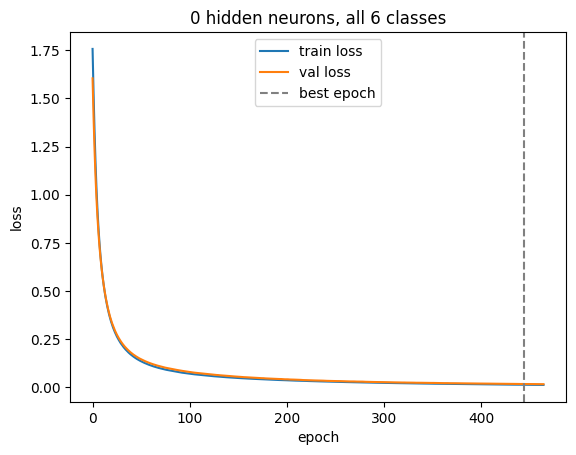

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.axvline(best_epoch, color="gray", linestyle="--", label="best epoch")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("0 hidden neurons, all 6 classes")
plt.show()

# Accuracy and F1 reporting not for the stopping decision

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate(model, X, y_true_idx):
    model.eval()
    with torch.no_grad():
        preds = model(X).argmax(dim=1).numpy()
    y_true = y_true_idx.numpy()
    acc = accuracy_score(y_true, preds)
    macro_f1 = f1_score(y_true, preds, average="macro")
    return acc, macro_f1

In [ ]:
val_acc, val_f1 = evaluate(net, X_v, y_v)
print(f"Val accuracy: {val_acc:.4f}  Val macro F1: {val_f1:.4f}")

Val accuracy: 1.0000  Val macro F1: 1.0000


# The sweep: hidden sizes 0 to 20, 5 seeds each

In [ ]:
hidden_sizes = list(range(0, 21))
n_seeds = 5

baseline_no_skill = no_skill_loss(y_train_t.numpy(), num_classes=6)  # same for every run here - all 6 classes, same train set

sweep_results = []

for h in hidden_sizes:
    for seed in range(n_seeds):
        torch.manual_seed(seed)
        net = GrowableNet(input_dim=34, output_dim=6, hidden_dim=h)
        history, best_epoch, best_val_loss = train_until_stagnation(
            net, X_train_t, y_train_t, X_val_t, y_val_t
        )
        verdict, train_loss, val_loss = diagnose(history, best_epoch, baseline_no_skill)
        val_acc, val_f1 = evaluate(net, X_val_t, y_val_t)

        sweep_results.append({
            "hidden_size": h, "seed": seed, "best_epoch": best_epoch,
            "train_loss": train_loss, "val_loss": val_loss,
            "val_acc": val_acc, "val_macro_f1": val_f1, "verdict": verdict,
        })

sweep_df = pd.DataFrame(sweep_results)
sweep_df.head()

,hidden_size,seed,best_epoch,train_loss,val_loss,val_acc,val_macro_f1,verdict
0,0,0,410,0.015396,0.020503,1.0,1.0,satisfactory
1,0,1,381,0.018033,0.021085,1.0,1.0,satisfactory
2,0,2,392,0.017965,0.021975,1.0,1.0,satisfactory
3,0,3,414,0.015833,0.020675,1.0,1.0,satisfactory
4,0,4,426,0.014350,0.018381,1.0,1.0,satisfactory


# Aggregate across seeds, so picking based on averages, not a lucky/unlucky run

In [ ]:
summary = sweep_df.groupby("hidden_size").agg(
    val_loss_mean=("val_loss", "mean"),
    val_loss_std=("val_loss", "std"),
    val_acc_mean=("val_acc", "mean"),
    val_macro_f1_mean=("val_macro_f1", "mean"),
    pct_overfit=("verdict", lambda v: (v == "overfitting").mean()),
    pct_underfit=("verdict", lambda v: (v == "underfitting").mean()),
).reset_index()
summary

,hidden_size,val_loss_mean,val_loss_std,val_acc_mean,val_macro_f1_mean,pct_overfit,pct_underfit
0,0,0.020524,0.001326,1.000000,1.000000,0.0,0.0
1,1,0.881118,0.123214,0.620339,0.378936,0.0,0.0
2,2,0.319942,0.103789,0.874576,0.732014,0.0,0.0
3,3,0.022734,0.013953,0.996610,0.997087,0.0,0.0
4,4,0.015758,0.007716,1.000000,1.000000,0.0,0.0
5,5,0.011079,0.004423,1.000000,1.000000,0.0,0.0
6,6,0.009117,0.001658,1.000000,1.000000,0.0,0.0
7,7,0.009176,0.002319,1.000000,1.000000,0.0,0.0
8,8,0.009030,0.002511,1.000000,1.000000,0.0,0.0
9,9,0.007087,0.000697,1.000000,1.000000,0.0,0.0


In [ ]:
def add_underfitting_flags(summary, threshold=0.02):
    """
    Retrospective check across the (independently-trained) sweep architectures:
    was there a meaningfully better *larger* architecture further along the sweep?
    Valid here specifically because every architecture is already fully trained -
    this is a description of what happened, not a live growth decision.
    """
    val_by_size = summary.set_index("hidden_size")["val_loss_mean"]
    running_min = np.inf
    best_forward = {}
    for h in sorted(summary["hidden_size"], reverse=True):
        best_forward[h] = running_min
        running_min = min(running_min, val_by_size[h])

    summary = summary.copy()
    summary["best_forward_val_loss"] = summary["hidden_size"].map(best_forward)
    summary["underfitting"] = (summary["val_loss_mean"] - summary["best_forward_val_loss"]) > threshold
    return summary

summary = add_underfitting_flags(summary)
summary

,hidden_size,val_loss_mean,val_loss_std,val_acc_mean,val_macro_f1_mean,pct_overfit,pct_underfit,best_forward_val_loss,underfitting
0,0,0.020524,0.001326,1.000000,1.000000,0.0,0.0,0.006799,False
1,1,0.881118,0.123214,0.620339,0.378936,0.0,0.0,0.006799,True
2,2,0.319942,0.103789,0.874576,0.732014,0.0,0.0,0.006799,True
3,3,0.022734,0.013953,0.996610,0.997087,0.0,0.0,0.006799,False
4,4,0.015758,0.007716,1.000000,1.000000,0.0,0.0,0.006799,False
5,5,0.011079,0.004423,1.000000,1.000000,0.0,0.0,0.006799,False
6,6,0.009117,0.001658,1.000000,1.000000,0.0,0.0,0.006799,False
7,7,0.009176,0.002319,1.000000,1.000000,0.0,0.0,0.006799,False
8,8,0.009030,0.002511,1.000000,1.000000,0.0,0.0,0.006799,False
9,9,0.007087,0.000697,1.000000,1.000000,0.0,0.0,0.006799,False


# One standard-error rule - simplest architecture within noise of the best

In [ ]:
best_val_loss_mean = summary["val_loss_mean"].min()
best_row_raw = summary.loc[summary["val_loss_mean"].idxmin()]
se = best_row_raw["val_loss_std"] / np.sqrt(n_seeds)

within_one_se = summary[summary["val_loss_mean"] <= best_val_loss_mean + se]
print("Architectures statistically tied with the best (within 1 SE):")
print(within_one_se[["hidden_size", "val_loss_mean", "val_macro_f1_mean"]])

selected = within_one_se.loc[within_one_se["val_macro_f1_mean"].idxmax()]
print(f"\nSelected baseline architecture: {int(selected['hidden_size'])} hidden neurons")
print(selected)

Architectures statistically tied with the best (within 1 SE):
    hidden_size  val_loss_mean  val_macro_f1_mean
10           10       0.006799                1.0

Selected baseline architecture: 10 hidden neurons
hidden_size                    10
val_loss_mean            0.006799
val_loss_std             0.000407
val_acc_mean                  1.0
val_macro_f1_mean             1.0
pct_overfit                   0.0
pct_underfit                  0.0
best_forward_val_loss    0.007016
underfitting                False
Name: 10, dtype: object


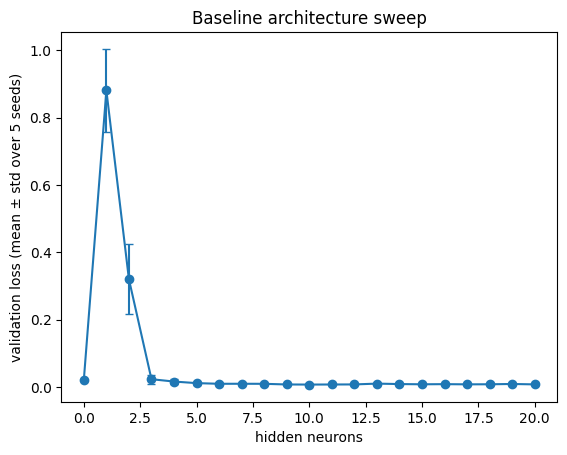

In [ ]:
plt.errorbar(summary["hidden_size"], summary["val_loss_mean"], yerr=summary["val_loss_std"], marker="o", capsize=3)
plt.xlabel("hidden neurons")
plt.ylabel("validation loss (mean ± std over 5 seeds)")
plt.title("Baseline architecture sweep")
plt.show()

The spike at h=1 (val_loss jumps to ~0.88, worse than h=0) is the same artifact documented for Yeast, not a bug - a single tanh neuron is a genuine optimisation bottleneck, harder for Adam to train through than either no hidden layer or a few more neurons giving it room to work. The curve recovers by h=3 and is flat and near-zero from there through h=20.

Notably, the one-SE rule selects h=10 despite h=0 already achieving val_acc=1.0 and val_macro_F1=1.0 - this isn't a contradiction. Accuracy/F1 saturate once every prediction is correct, but cross-entropy loss keeps improving with more confident (higher-margin) correct predictions, and h=10's val_loss_std is small enough (0.0004) that the 1-SE window is very narrow. Baseline needs meaningfully less capacity here than Glass (16) or Yeast (25), but not zero.

# Graph for report

In [ ]:
# check whether any architecture in the sweep was flagged as overfitting
overfit_runs = sweep_df[sweep_df["verdict"] == "overfitting"]
print(f"{len(overfit_runs)} of {len(sweep_df)} sweep runs flagged as overfitting")
print(overfit_runs[["hidden_size", "seed", "val_loss"]])

0 of 105 sweep runs flagged as overfitting
Empty DataFrame
Columns: [hidden_size, seed, val_loss]
Index: []


# Test evaluation with the selected architecture

In [ ]:
BASELINE_HIDDEN_SIZE = 10
baseline_test_results = []

for seed in range(n_seeds):
    torch.manual_seed(seed)
    net = GrowableNet(input_dim=34, output_dim=6, hidden_dim=BASELINE_HIDDEN_SIZE)
    history, best_epoch, best_val_loss = train_until_stagnation(
        net, X_train_t, y_train_t, X_val_t, y_val_t
    )
    test_acc, test_f1 = evaluate(net, X_test_t, y_test_t)

    baseline_test_results.append({
        "seed": seed, "hidden_size": BASELINE_HIDDEN_SIZE,
        "best_epoch": best_epoch + 1,
        "val_loss": best_val_loss,
        "test_acc": test_acc, "test_macro_f1": test_f1,
    })

baseline_test_df = pd.DataFrame(baseline_test_results)
baseline_test_df

,seed,hidden_size,best_epoch,val_loss,test_acc,test_macro_f1
0,0,10,269,0.007485,0.972973,0.971855
1,1,10,265,0.006717,0.972973,0.971855
2,2,10,260,0.006495,0.959459,0.957362
3,3,10,252,0.006803,0.972973,0.971855
4,4,10,268,0.006496,0.959459,0.956013


# Confusion matrices per seed

In [ ]:
from sklearn.metrics import confusion_matrix

class_names_ordered = [CLASS_NAMES[index_to_label[i]] for i in range(6)]

for seed in range(n_seeds):
    torch.manual_seed(seed)
    net = GrowableNet(input_dim=34, output_dim=6, hidden_dim=BASELINE_HIDDEN_SIZE)
    train_until_stagnation(net, X_train_t, y_train_t, X_val_t, y_val_t)

    with torch.no_grad():
        preds = net(X_test_t).argmax(dim=1).numpy()
    cm = confusion_matrix(y_test_t.numpy(), preds, labels=range(6))

    print(f"\n--- seed {seed} ---")
    print(pd.DataFrame(cm, index=class_names_ordered, columns=class_names_ordered))


--- seed 0 ---
                          pityriasis_rubra_pilaris  pityriasis_rosea  \
pityriasis_rubra_pilaris                         4                 0   
pityriasis_rosea                                 0                10   
chronic_dermatitis                               0                 0   
seboreic_dermatitis                              0                 1   
lichen_planus                                    0                 1   
psoriasis                                        0                 0   

                          chronic_dermatitis  seboreic_dermatitis  \
pityriasis_rubra_pilaris                   0                    0   
pityriasis_rosea                           0                    0   
chronic_dermatitis                        10                    0   
seboreic_dermatitis                        0                   11   
lichen_planus                              0                    0   
psoriasis                                  0                    0

`pityriasis_rubra_pilaris` (the rarest class) is classified perfectly in every seed - 4/4 test instances correct across all 5 runs, unlike Glass's catastrophic minority-class failure or Yeast's majority-class blurring. `chronic_dermatitis` and `psoriasis` are also perfect in every seed. All errors (2-3 total per seed, out of 74) involve `seboreic_dermatitis` or `lichen_planus` being confused with `pityriasis_rosea` (and once with `chronic_dermatitis`), never with `pityriasis_rubra_pilaris`. This is a fundamentally different error pattern from Glass and Yeast: the confusion here is concentrated among mid-frequency classes, not the rarest one, consistent with the earlier finding that `pityriasis_rubra_pilaris` has unusually strong, near-exclusive discriminative features (`follicular_horn_plug`, `perifollicular_parakeratosis`, distinctive age).

In [ ]:
sweep_df.to_csv(data_dir + "baseline_sweep_results.csv", index=False)
summary.to_csv(data_dir + "baseline_sweep_summary.csv", index=False)
baseline_test_df.to_csv(data_dir + "baseline_test_results.csv", index=False)
print("Saved baseline sweep, summary, and final test results to Drive.")

Saved baseline sweep, summary, and final test results to Drive.


# per-instance predictions for the incremental models (needed for the paired test)

In [ ]:
criterion_ni = nn.CrossEntropyLoss(reduction="none")
baseline_instance_records = []

for seed in range(n_seeds):
    torch.manual_seed(seed)
    net = GrowableNet(input_dim=34, output_dim=6, hidden_dim=BASELINE_HIDDEN_SIZE)
    train_until_stagnation(net, X_train_t, y_train_t, X_val_t, y_val_t)

    net.eval()
    with torch.no_grad():
        logits = net(X_test_t)
        per_instance_loss = criterion_ni(logits, y_test_t).numpy()
        preds = logits.argmax(dim=1).numpy()

    for i in range(len(y_test_t)):
        baseline_instance_records.append({
            "seed": seed, "instance": i,
            "true_class": y_test_t[i].item(),
            "pred_class": int(preds[i]),
            "loss": float(per_instance_loss[i]),
        })

baseline_instance_df = pd.DataFrame(baseline_instance_records)
baseline_instance_df.to_csv(data_dir + "baseline_instance_results.csv", index=False)
print("Saved per-instance baseline results for the paired Wilcoxon test.")
baseline_instance_df.head()

Saved per-instance baseline results for the paired Wilcoxon test.


,seed,instance,true_class,pred_class,loss
0,0,0,3,3,0.016997
1,0,1,4,4,0.001423
2,0,2,1,1,0.000287
3,0,3,5,5,0.003299
4,0,4,1,1,0.000696


In [ ]:
from sklearn.metrics import recall_score

baseline_recall_runs = []
for seed in range(n_seeds):
    torch.manual_seed(seed)
    net = GrowableNet(input_dim=34, output_dim=6, hidden_dim=BASELINE_HIDDEN_SIZE)
    train_until_stagnation(net, X_train_t, y_train_t, X_val_t, y_val_t)
    with torch.no_grad():
        preds = net(X_test_t).argmax(dim=1).numpy()
    baseline_recall_runs.append(recall_score(y_test_t.numpy(), preds, labels=range(6), average=None))

baseline_recall = np.mean(baseline_recall_runs, axis=0)
pd.DataFrame({"class": class_names_ordered, "baseline_recall": baseline_recall}).to_csv(data_dir + "baseline_recall.csv", index=False)
print("Saved per-class baseline recall.")
pd.DataFrame({"class": class_names_ordered, "baseline_recall": baseline_recall})

Saved per-class baseline recall.


,class,baseline_recall
0,pityriasis_rubra_pilaris,1.000000
1,pityriasis_rosea,1.000000
2,chronic_dermatitis,1.000000
3,seboreic_dermatitis,0.883333
4,lichen_planus,0.933333
5,psoriasis,1.000000
